In [1]:
!pip install torch matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim #optimization algorithms
import matplotlib.pyplot as plt

In [26]:
x = torch.tensor([[1.0],[2.0],[3.0],[4.0],[5.0]]) # inputs
y = torch.tensor([[3.0],[5.0],[7.0],[9.0],[11.0]]) # targets

In [27]:
model = nn.Linear(1,1) #y = wx+b

In [28]:
for name, param in model.named_parameters():
  print(f"{name}")
  print(param.data)
  print("Shape : ",param.shape)
  print("\n")

weight
tensor([[0.6847]])
Shape :  torch.Size([1, 1])


bias
tensor([-0.0078])
Shape :  torch.Size([1])




In [29]:
for param in model.parameters():
  print(param)

Parameter containing:
tensor([[0.6847]], requires_grad=True)
Parameter containing:
tensor([-0.0078], requires_grad=True)


In [30]:
print(f"initial weight : {model.weight.data}")
print(f"intial bias : {model.bias.data}")

initial weight : tensor([[0.6847]])
intial bias : tensor([-0.0078])


In [31]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),lr = 0.01)
print("criterion is this : ",criterion)
print("\n")
print(optimizer)

criterion is this :  MSELoss()


SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


In [32]:
with torch.no_grad():
  preds = model(x)

In [33]:
print("before training")
print(preds)

before training
tensor([[0.6768],
        [1.3615],
        [2.0462],
        [2.7309],
        [3.4155]])


In [34]:
epochs = 20
losses = []
for epoch in range(epochs):

  #forward pass
  predictions = model(x)

  # calculate loss
  loss = criterion(predictions, y)

  #backward pass # dw
  optimizer.zero_grad()
  loss.backward()

  #update weights - new weight = old weight - lr*dw
  optimizer.step()

  losses.append(loss.item())

  if epoch%2 == 0 :
    print(f"Epoch {epoch},Loss : {loss.item():.4f}")

Epoch 0,Loss : 28.0004
Epoch 2,Loss : 9.5509
Epoch 4,Loss : 3.2850
Epoch 6,Loss : 1.1565
Epoch 8,Loss : 0.4331
Epoch 10,Loss : 0.1869
Epoch 12,Loss : 0.1028
Epoch 14,Loss : 0.0737
Epoch 16,Loss : 0.0633
Epoch 18,Loss : 0.0592


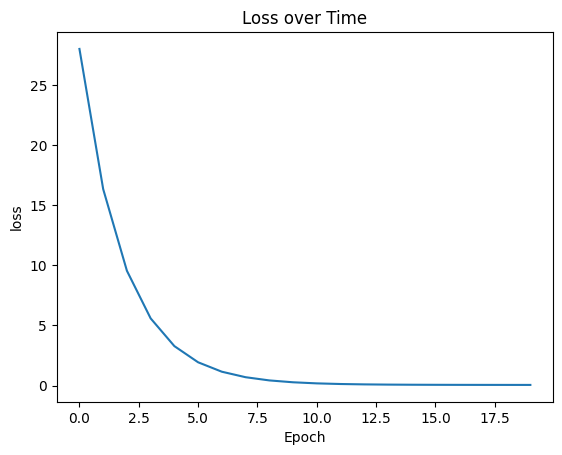

In [35]:
plt.plot(losses)
plt.title("Loss over Time")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.show()

In [36]:
print("trained weight :", model.weight.data)
print("trained bias : ", model.bias.data)

trained weight : tensor([[2.1480]])
trained bias :  tensor([0.4396])


In [37]:
with torch.no_grad():
  preds = model(x)

print("Predictions after training :",preds)

Predictions after training : tensor([[ 2.5876],
        [ 4.7357],
        [ 6.8837],
        [ 9.0317],
        [11.1797]])


In [38]:
z = torch.tensor([[9.0]])

In [39]:
with torch.no_grad():
  pred_1 = model(z)

print("For unseen data : ",pred_1)

For unseen data :  tensor([[19.7717]])


In [44]:
model_high_lr = nn.Linear(1,1)
optimizer_high = optim.SGD(model_high_lr.parameters(),lr = 1.0)

In [45]:
with torch.no_grad():
  preds = model_high_lr(x)

In [46]:
print("before training")
print(preds)

before training
tensor([[0.6646],
        [1.5321],
        [2.3995],
        [3.2670],
        [4.1345]])


In [55]:
epochs = 20
losses_high = []
for epoch in range(epochs):

  #forward pass
  predictions_high = model_high_lr(x)

  # calculate loss
  loss_high = criterion(predictions_high, y)

  #backward pass # dw
  optimizer_high.zero_grad()
  loss_high.backward()

  #update weights - new weight = old weight - lr*dw
  optimizer_high.step()

  losses_high.append(loss_high.item())

  if epoch%2 == 0 :
    print(f"Epoch {epoch},Loss : {loss_high.item():.4f}")

Epoch 0,Loss : 23.7294
Epoch 2,Loss : 6225786.0000
Epoch 4,Loss : 1642024927232.0000
Epoch 6,Loss : 433077289215852544.0000
Epoch 8,Loss : 114222338383601345757184.0000
Epoch 10,Loss : 30125671123792817020798500864.0000
Epoch 12,Loss : 7945520071746927633596044971868160.0000
Epoch 14,Loss : inf
Epoch 16,Loss : inf
Epoch 18,Loss : inf


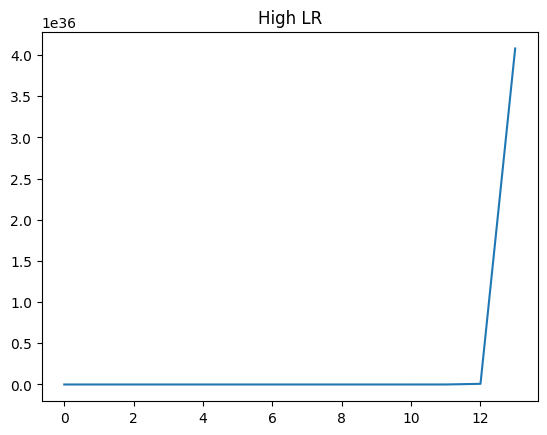

In [64]:
plt.plot(losses_high)
plt.title("High LR")
plt.show()

In [57]:
model_low_lr = nn.Linear(1,1)
optimizer_low = optim.SGD(model_low_lr.parameters(),lr = 1.0)
with torch.no_grad():
  preds = model_low_lr(x)
print("before training")
print(preds)

before training
tensor([[1.0416],
        [1.9762],
        [2.9109],
        [3.8455],
        [4.7801]])


In [58]:
epochs = 20
losses_low = []
for epoch in range(epochs):

  #forward pass
  predictions_low = model_low_lr(x)

  # calculate loss
  loss_low = criterion(predictions_low, y)

  #backward pass # dw
  optimizer_low.zero_grad()
  loss_low.backward()

  #update weights - new weight = old weight - lr*dw
  optimizer_low.step()

  losses_low.append(loss_low.item())

  if epoch%2 == 0 :
    print(f"Epoch {epoch},Loss : {loss_low.item():.4f}")

Epoch 0,Loss : 18.9910
Epoch 2,Loss : 18.8124
Epoch 4,Loss : 18.6355
Epoch 6,Loss : 18.4603
Epoch 8,Loss : 18.2867
Epoch 10,Loss : 18.1147
Epoch 12,Loss : 17.9444
Epoch 14,Loss : 17.7757
Epoch 16,Loss : 17.6086
Epoch 18,Loss : 17.4430


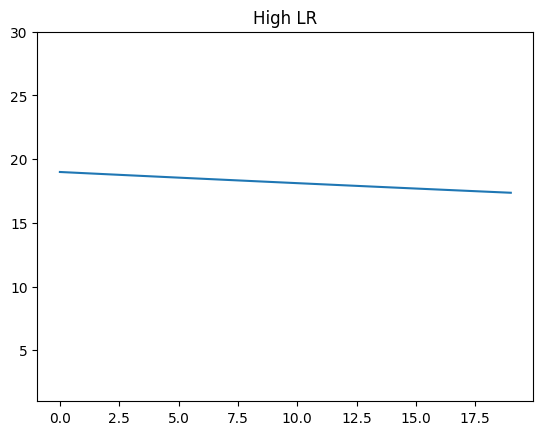

In [62]:
plt.ylim(1,30)
plt.plot(losses_low)
plt.title("High LR")
plt.show()